# SDSS Log Exploration

## Find version with most logged data

Endpoint: http://skyserver.sdss.org/log/en/traffic/sql.asp

``` mysql
SELECT dbname,count(1)
FROM SqlLog
where lower(dbname) like 'bestdr%'
group by dbname
order by count(1) desc
``` 

In [1]:
import pandas as pd
df = pd.read_csv('data/raw/count_db.csv')
df[0:10]

,dbname,Unnamed: 1
0,BestDR7,131202363
1,BestDR12,87438589
2,BestDR6,67512542
3,BestDR9,40343940
4,BestDR14_SSD,39199085
5,BestDR5,31233795
6,BestDR8,24133391
7,BestDR10,24070988
8,BestDR16,20604171
9,BestDR4,17347428


## Count valid logs

Count how many statements from the query log regarding the DR7 schema are valid and return results.
``` mysql
SELECT count(1)
FROM SqlLog
where lower(dbname) = 'bestdr7' and
lower(statement) like 'select%from%' and
error = 0 and 
rows > 0
```

Returns 82.437.254



Remove functions and unwanted schemas/tables
``` mysql
SELECT count(1)
FROM SqlLog
WHERE 
error=0 and 
rows>0 and
lower(dbname) = 'bestdr7' and
lower(statement) like 'select%from%' and
lower(statement) not like '%fget%' and
lower(statement) not like '%mydb.%' and
lower(statement) not like '%fdoc%' and
lower(statement) not like '%dbobjects%' and
lower(statement) not like '%sqllog%' and
lower(statement) not like '%sys.%' and
lower(statement) not like '%information_schema.%' and
lower(statement) not like '%ffootprinteq%' and
lower(statement) not like '%count(*)%' and
lower(statement) not like '%select *%' and
len(statement) < 500
``` 
Returns 21.409.362

## Get Query Log 
Ignoring 14 ips that have executed more than 200.000 queries

Query for log.csv:
``` mysql
SELECT clientIP, REPLACE(REPLACE(REPLACE(REPLACE(lower(statement),
CHAR(13) + CHAR(10), ' '),
CHAR(13), ' '),
CHAR(10), ' '),
'bestdr7..','')
 as sql
FROM SqlLog
WHERE
error=0 and
clientIP NOT IN ('172.23.250.207','141.211.198.86','133.56.195.32','129.234.252.65','129.234.252.65', '142.104.62.83', '158.109.72.6',  '131.215.198.33' , '146.155.21.21', '129.234.184.52',  '131.111.69.171',  '132.236.7.132', '131.215.194.33', '128.135.4.42') and
lower(dbname) = 'bestdr7' and
lower(statement) like 'select%from%' and
lower(statement) not like '%fget%' and
lower(statement) not like '%mydb.%' and
lower(statement) not like '%fdoc%' and
lower(statement) not like '%dbobjects%' and
lower(statement) not like '%sqllog%' and
lower(statement) not like '%sys.%' and
lower(statement) not like '%#x%' and
lower(statement) not like '%#upload%' and
lower(statement) not like '%dbviewcols%' and
lower(statement) not like '%information_schema.%' and
lower(statement) not like '%ffootprinteq%' and
lower(statement) not like '%count(*)%' and
lower(statement) not like '%select *%' and
len(statement) < 500
order by theTime asc
```

In [2]:
# Count total queries in log.csv
!wc -l 'data/raw/log.csv'

 8251062 data/raw/log.csv


## Parse user information

In [1]:
from sqlcompletions.processing import create_query_log

log = create_query_log()
log.users()
log.ips.most_common()[0:11]

Queries in the log: 8251061
Users in the log: 21043


[('149.217.40.222', 770922),
 ('149.217.1.6', 228683),
 ('128.138.116.39', 213603),
 ('131.220.96.41', 178968),
 ('204.174.103.3', 166124),
 ('138.232.146.75', 157746),
 ('134.147.158.25', 157559),
 ('81.36.180.92', 129253),
 ('143.117.54.124', 128377),
 ('147.197.230.34', 127743),
 ('147.197.230.31', 124810)]

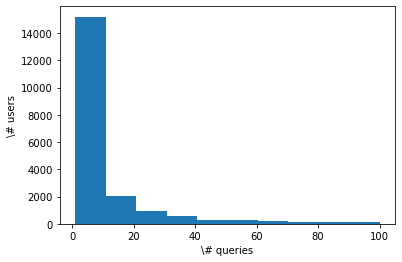

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


x = [x for x in log.ips.values()]
plt.hist(x,range=(1,100))
plt.xlabel("\# queries")
plt.ylabel("\# users")

import tikzplotlib
tikzplotlib.save("plots/user_queries.tex", extra_axis_parameters=["scaled x ticks=false","scaled y ticks=false"],
axis_height = '\\figH',
    axis_width = '\\figW')


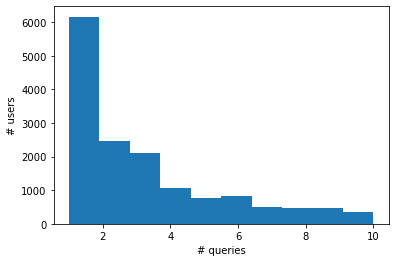

In [10]:
plt.hist(x,range=(1,10))
plt.xlabel("# queries")
plt.ylabel("# users")
plt.show()

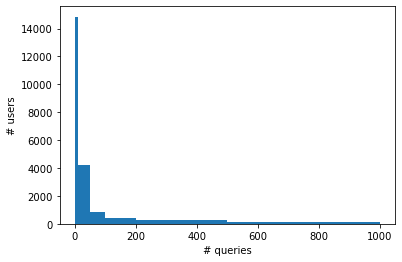

In [6]:
plt.hist(x,bins=[1,10,50,100,200,500,1000])
plt.xlabel("# queries")
plt.ylabel("# users")
plt.show()

In [11]:
# how many users have executed 1 query
sum([1 for x in log.ips.values() if x == 1])

6160

In [7]:
# Find how many queries the top 100 users have executed
top_users = 0
for ip in log.ips.most_common()[0:100]:
    top_users += ip[1]

print("Total:", top_users, "Percentage:",round(top_users/log.total_queries*100,1),'%')
print("Queries that will remain:", log.total_queries -top_users )

Total: 6826851 Percentage: 82.7 %
Queries that will remain: 1424210


In [8]:
# How many queries the 100th top user has executed
log.ips.most_common()[100]

('88.19.158.144', 16148)

In [9]:
log.ips.most_common()[1000]

('183.60.213.24', 125)

In [10]:
# count users with less than 3 queries
len([x for x in log.ips.values() if x < 3])

8630

In [11]:
# View different scenarios with threshold in the number of queries
def count_with_threshold(th):
    count_queries = 0
    count_users = 0
    for ip in log.ips.values():
        if ip <= th:
            count_queries += ip
            count_users +=1
    print("Threshold:",th,"Queries:",count_queries,"Users:",count_users,"Blacklist:",len(log.ips)-count_users)

thresholds = [10,15,20,50,100,500,1000,2000,5000]
for th in thresholds:
    count_with_threshold(th)

Threshold: 10 Queries: 42070 Users: 14848 Blacklist: 6195
Threshold: 15 Queries: 58734 Users: 16269 Blacklist: 4774
Threshold: 20 Queries: 73568 Users: 17153 Blacklist: 3890
Threshold: 50 Queries: 131664 Users: 19050 Blacklist: 1993
Threshold: 100 Queries: 190266 Users: 19896 Blacklist: 1147
Threshold: 500 Queries: 327536 Users: 20547 Blacklist: 496
Threshold: 1000 Queries: 435156 Users: 20696 Blacklist: 347
Threshold: 2000 Queries: 563667 Users: 20787 Blacklist: 256
Threshold: 5000 Queries: 862500 Users: 20882 Blacklist: 161


In [12]:
log.ips.most_common()[200]

('131.142.188.53', 3199)

In [1]:
!grep '131.142.188.53' 'data/raw/log.csv' | head -n5

131.142.188.53,"select objid,specobjid from specphoto where fieldid=758879801989005312 or fieldid=758879802245185536    "
131.142.188.53,"select objid,specobjid from specphoto where fieldid=587746044102180864 or fieldid=587746044102246400 or fieldid=587746044357050368    "
131.142.188.53,"select objid,status,ra,dec,petromag_r,fibermag_g,fibermag_r,fibermag_i, extinction_r,extinction_g,extinction_i from photoobjall where ra between 49.56109587 and 49.56276253 and dec between -3.05693333 and -3.05526667    "
131.142.188.53,"select objid,status,ra,dec,petromag_r,fibermag_g,fibermag_r,fibermag_i, extinction_r,extinction_g,extinction_i from photoobjall where ra between 49.40954997 and 49.41121663 and dec between -3.03444722 and -3.03278056    "
131.142.188.53,"select objid,status,ra,dec,petromag_r,fibermag_g,fibermag_r,fibermag_i, extinction_r,extinction_g,extinction_i from photoobjall where ra between 49.57327917 and 49.57494583 and dec between -3.03523333 and -3.03356667    "


## Create Logs

In [2]:
from sqlcompletions.processing import create_query_log

In [1]:
log = create_query_log(threshold=50)

Queries in the log: 8251061
Users in the log: 21043


100%|█████████▉| 8251061/8251062 [00:07<00:00, 1032023.75it/s]


 
Queries after removing blacklisted users: 132024
Queries after removing duplicates: 101662
Distinct queries: 61295 out of 101661 valid queries 60 %
Total unique errors: 501
Parsed distinct queries: 59299 out of 61295 97 %
Failed to parse: 2330
Final queries: 99331


In [1]:
log = create_query_log(threshold=50)

Queries in the log: 8251061
Users in the log: 21043


100%|█████████▉| 8251061/8251062 [00:09<00:00, 871317.46it/s] 

---------- Hash Phase ----------
Queries after removing blacklisted users: 131713
Queries after removing duplicates: 101389
Distinct queries: 61044 out of 101388 valid queries 60 %
Total users: 19017


---------- Parse Phase ----------
Total unique errors: 499
Parsed distinct queries: 59132 out of 61044 97 %
Failed to parse: 2244
Final queries: 99144 Users: 18793 Distinct: 59132 60 %


In [2]:
log = create_query_log(threshold=100)

Queries in the log: 8251061
Users in the log: 21043


100%|█████████▉| 8251061/8251062 [00:09<00:00, 856080.01it/s] 


---------- Hash Phase ----------
Queries after removing blacklisted users: 189333
Queries after removing duplicates: 143958
Distinct queries: 86316 out of 143957 valid queries 60 %
Total users: 19847
---------- Parse Phase ----------
Total unique errors: 574
Parsed distinct queries: 83660 out of 86316 97 %
Failed to parse: 3054
Final queries: 140903 Users: 19622 Distinct: 83660 59 %


In [3]:
log = create_query_log(threshold=500)

Queries in the log: 8251061
Users in the log: 21043


100%|█████████▉| 8251061/8251062 [00:09<00:00, 841879.57it/s] 


---------- Hash Phase ----------
Queries after removing blacklisted users: 324083
Queries after removing duplicates: 241993
Distinct queries: 137285 out of 241992 valid queries 57 %
Total users: 20488
---------- Parse Phase ----------
Total unique errors: 681
Parsed distinct queries: 133165 out of 137285 97 %
Failed to parse: 5000
Final queries: 236992 Users: 20261 Distinct: 133165 56 %


In [3]:
log = create_query_log(lower_threshold=10, threshold=500)

Queries in the log: 8251061
Users in the log: 21043


100%|█████████▉| 8251061/8251062 [00:09<00:00, 853545.29it/s] 


---------- Hash Phase ----------
Queries after removing blacklisted users: 282325
Queries after removing duplicates: 208121
Distinct queries: 122164 out of 208120 valid queries 59 %
Total users: 5691
---------- Parse Phase ----------
Total unique errors: 491
Parsed distinct queries: 118735 out of 122164 97 %
Failed to parse: 4114
Final queries: 204006 Users: 5678 Distinct: 118735 58 %


In [2]:
!head -n3 'data/processed/log_th50.json'

[[], [89], [], 1]
[[], [66], [], 2]
[[3081, 3375, 3456], [100], [], 1]


In [1]:
import json
from collections import Counter

with open('data/processed/errors.json') as json_file:
    data = json.load(json_file)

errors = Counter({x[0]:x[1] for x in data})
errors.most_common(10)

[("'Token' object has no attribute 'tokens'", 311),
 ('Table z not in schema', 100),
 ('Table s not in schema', 65),
 ('Table specobjid not in schema', 55),
 ('Table ra not in schema', 55),
 ('Table photobj not in schema', 46),
 ('Table seg not in schema', 35),
 ('Table galaxies not in schema', 34),
 ('list index out of range', 31),
 ('Table b not in schema', 26)]

# Log analysis

In [2]:
from sqlcompletions.sqlparser import schema

db = schema()
db.n_columns

9903

In [3]:
db.n_tables

167

## Stats for logs

#### Average occurrences for each clause

In [5]:
import json
from sqlcompletions.processing import statistics

def averages(file="log_th50.json", max_iterations=None, skip_lines=None):
    log = open("data/processed/"+file)

    if skip_lines is not None:
        for _ in range(skip_lines):
            next(log)

    # log = tqdm(log, total=max_iterations)

    users = {}
    counts = [0, 0, 0]

    i = 0
    for line in log:
        i += 1
        row = json.loads(line)
        user = row[-1]
        if user not in users:
            users[user] = True

        for j in range(3):
            counts[j] += len(row[j])

        if max_iterations and i > max_iterations:
            break

    counts = [round(x / i, 1) for x in counts]
    # print("Averages:", counts)
    # print("Distinct users", len(users.keys()))
    results = zip(["Select","From","Where","Group By","Order By"],counts)
    print(list(results))

In [6]:
for th in [50]:
    print('-'*20, 'TH',th, '-'*20)
    log = "log_th"+str(th)+".json"
    averages(log)
    stats = statistics(log)
    stats.most_popular_identifiers(5)
    stats.used_identifiers()

-------------------- TH 50 --------------------
[('Select', 6.1), ('From', 1.4), ('Where', 2.5)]
Select : 92688 events
From : 98886 events
Where : 85970 events
{'Select': [('specobj.z', 25770), ('indexmap.fieldlist', 17341), ('indexmap.tablename', 17327), ('indexmap.foreignkey', 17262), ('indexmap.code', 17260)], 'From': [('specobj', 45396), ('photoobj', 25693), ('indexmap', 17410), ('galaxy', 10545), ('star', 6497)], 'Where': [('specobj.z', 24574), ('specobj.bestobjid', 22404), ('photoobj.objid', 20319), ('indexmap.tablename', 15524), ('specobj.zconf', 11081)]}
Select clause used identifiers: 2413 out of 9903 24 %
From clause used identifiers: 109 out of 167 65 %
Where clause used identifiers: 966 out of 9903 10 %


In [8]:
from sqlcompletions.processing import statistics
for th in [500]:
    print('-'*20, 'TH',th, '-'*20)
    log = "log_th"+str(th)+".json"
    stats = statistics(log)
    stats.most_popular_identifiers(20)

-------------------- TH 500 --------------------
Select : 224847 events
From : 236545 events
Where : 210444 events
{'Select': [('indexmap.fieldlist', 55245), ('indexmap.tablename', 55128), ('indexmap.foreignkey', 54754), ('indexmap.code', 54752), ('indexmap.indexmapid', 54752), ('indexmap.type', 54752), ('specobj.z', 52893), ('photoobj.dec', 35394), ('photoobj.ra', 35302), ('photoobj.objid', 33908), ('specobj.specobjid', 27690), ('specobj.fiberid', 25436), ('specobj.specclass', 24652), ('specobj.plate', 23972), ('specobj.mjd', 23804), ('photoobj.r', 22937), ('photoobj.g', 21429), ('specobj.dec', 21228), ('photoobj.u', 21139), ('specobj.ra', 21049)], 'From': [('specobj', 88046), ('indexmap', 55624), ('photoobj', 53266), ('galaxy', 22940), ('star', 14741), ('photoobjall', 10889), ('specphoto', 7730), ('sppparams', 7649), ('specobjall', 6986), ('specline', 6834), ('photoprimary', 6069), ('field', 4560), ('photoz', 4311), ('specphotoall', 3401), ('platex', 3342), ('phototag', 2343), ('spec

## Average Pool length for Where Clause

In [3]:
import json
from sqlcompletions.sqlparser import schema

db = schema()

clause = 0
log_file = "data/processed/log_th50.json"

avg = 0
i=0
for line in open(log_file):
    try:
        row = json.loads(line)
        target = row[clause]
        n_target = len(target)
    except Exception:
        n_target = 0
        continue

    if n_target > 0:
        i+=1
        pool = []
        for table in row[1]:
            pool.extend(db.schema_idx[table])
        avg += (len(pool) - avg) / i
avg

272.6327414842316

# Analyze user execution templates

Text(0, 0.5, '# users')

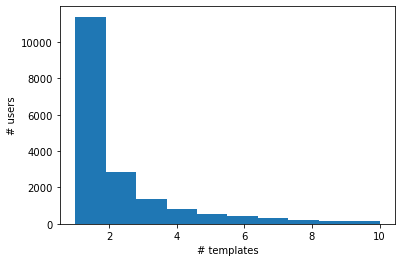

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import json

log_file = "data/processed/log_th50.json"

users = {}
users_count_distinct = {}
users_count = {}
for line in open(log_file):
    row = json.loads(line)
    user = row[-1]
    if user not in users:
        users[user] = {}
        users_count_distinct[user] = 0
        users_count[user] = 0

    q = hash(str(row[0:3]))
    if q not in users[user]:
        users[user][q] = 1
        users_count_distinct[user] += 1
    else:
        users[user][q] +=1

    users_count[user]+=1

        
# plt.hist(users_count_distinct.values())    
plt.hist(users_count_distinct.values(),range=(1,10))
plt.xlabel("# templates")
plt.ylabel("# users")


Text(0, 0.5, '# users')

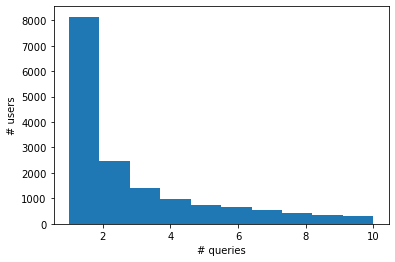

In [7]:
plt.hist(users_count.values(),range=(1,10))
plt.xlabel("# queries")
plt.ylabel("# users")

In [5]:
# maximum number of different templates executed by same user
max(users_count_distinct.values())

33